# Project Master Runner

This is the central entry point for the **Ecommerce Sentiment Analysis** project. It imports the logic from internal notebooks and executes the analysis pipeline using TensorFlow Metal acceleration.

## 1. Data Exploration & Cleaning

In [2]:
%load_ext autoreload
%autoreload 2

# Import the DataExploration class from the notebooks folder
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath('notebooks'))

from notebooks.CapstoneData import DataExploration

# Define the dataset path
data_path = 'Ecommerce_dataset/train_data.csv'

# Instantiate and run the analysis
eda = DataExploration(data_path)
eda.get_summary()
eda.get_sentiment_distribution()
eda.remove_nulls(columns=['reviews.text', 'sentiment'])

print(f"\nCleaned data ready with {len(eda.df)} rows.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dataset loaded successfully with 4001 rows and 8 columns.

DATASET SUMMARY

--- First 5 rows ---
                                                name   brand  \
0  All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...  Amazon   
1        Amazon - Echo Plus w/ Built-In Hub - Silver  Amazon   
2  Amazon Echo Show Alexa-enabled Bluetooth Speak...  Amazon   
3  Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...  Amazon   
4  Brand New Amazon Kindle Fire 16gb 7" Ips Displ...  Amazon   

                                          categories  \
0  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
1  Amazon Echo,Smart Home,Networking,Home & Tools...   
2  Amazon Echo,Virtual Assistant Speakers,Electro...   
3  eBook Readers,Fire Tablets,Electronics Feature...   
4  Computers/Tablets & Networking,Tablets & eBook...   

             primaryCategories              reviews.date  \
0                  Electronics  2

## 2. Model Training & Validation

Run the cell below to execute **`train_and_validate.py`** in-process: it trains all seven models on the cleaned `eda.df`, writes artifacts under **`deploy_models/`**, evaluates on **`Ecommerce_dataset/test_data_hidden.csv`**, and saves metrics plus charts under **`validation_outputs/`** (confusion matrices, macro P/R/F1, per-class heatmaps, accuracy bars, `metrics_summary.csv`).

Implementation lives in `train_and_validate.py` (`run_pipeline`). Terminal: `python train_and_validate.py`. To **only** re-run evaluation and plots from existing checkpoints: `python validate_deploy_models.py`.

> **Note:** BERT / DistilBERT / RoBERTa / DeBERTa / RNN use TensorFlow with Metal GPU when available.

In [3]:
import os
import sys

# Project root must be on sys.path and the working directory (train_and_validate pins both on import)
_REPO_ROOT = os.path.abspath(os.getcwd())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

import train_and_validate as tv

# Train on notebook EDA DataFrame; validate on hidden test set; save under deploy_models/
results = tv.run_pipeline(eda.df)

/Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

--- Training Logistic Regression ---
DataFrame provided directly with 3599 rows.

Cleaning Complete: Removed 8 rows with null values.
New row count: 3591

DATASET SUMMARY

--- First 5 rows ---
                                                name   brand  \
0  All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...  Amazon   
1        Amazon - Echo Plus w/ Built-In Hub - Silver  Amazon   
2  Amazon Echo Show Alexa-enabled Bluetooth Speak...  Amazon   
3  Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...  Amazon   
4  Brand New Amazon Kindle Fire 16gb 7" Ips Displ...  Amazon   

                                          categories  \
0  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
1  Amazon Echo,Smart Home,Networking,Home & Tools...   
2  Amazon Echo,Virtual Assistant Speakers,Electro...   
3  eBook Readers,Fire Tablets,Electronics Feature...   
4  Computers/Tablets & Networking,Tablets & eBook...   

 

2026-03-29 20:03:30.803981: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-03-29 20:03:30.804013: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-03-29 20:03:30.804022: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
2026-03-29 20:03:30.804045: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-29 20:03:30.804056: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-29 20:03:31.509093: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


223/223 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.3406 - loss: 1.1134 - val_accuracy: 0.3351 - val_loss: 1.0986 - learning_rate: 8.0000e-04
Epoch 2/24
223/223 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.3453 - loss: 1.1123 - val_accuracy: 0.3412 - val_loss: 1.1001 - learning_rate: 8.0000e-04
Epoch 3/24
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3239 - loss: 1.1164
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00035999999090563506.
223/223 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.3240 - loss: 1.1164 - val_accuracy: 0.3237 - val_loss: 1.0989 - learning_rate: 8.0000e-04
Epoch 4/24
223/223 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.3189 - loss: 1.1054 - val_accuracy: 0.3412 - val_loss: 1.0985 - learning_rate: 3.6000e-04
Epoch 5/24
223/223 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.3478 - loss: 1.1038 - val_accuracy: 0.3237 - val_loss: 1.0993 - learning_rate: 3.6000e-04
Epoch 6/24
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


...

Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_roberta_hf_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_roberta_hf_tf
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFDebertaV2ForSequenceClassification.

All the layers of TFDebertaV2ForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2ForSequenceClassification for predictions without further training.
The tokenizer you are loading from '/Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf

[Logistic]
              precision    recall  f1-score   support

    Negative       0.33      0.54      0.41        24
     Neutral       0.88      0.18      0.30        39
    Positive       0.96      0.98      0.97       934

    accuracy                           0.94       997
   macro avg       0.72      0.57      0.56       997
weighted avg       0.94      0.94      0.93       997

Accuracy: 0.9378134403209629

[SVM]
              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50        24
     Neutral       0.89      0.21      0.33        39
    Positive       0.95      1.00      0.98       934

    accuracy                           0.95       997
   macro avg       0.95      0.51      0.60       997
weighted avg       0.95      0.95      0.94       997

Accuracy: 0.9528585757271816

[RNN]
              precisi

## 3. Sentiment Models Initialization & Comparison

**After Section 2 finishes** (training + validation on the hidden test set), artifacts live under `deploy_models/`. Run this cell to load every saved model into the `models` dict for Sections 4–5.

If you trained from a terminal instead (`python train_and_validate.py`), run Section 2’s imports once from the repo root, or `os.chdir` to the project root before this cell so paths resolve.

In [4]:
import os
import sys

sys.path.append(os.path.abspath('notebooks'))

from notebooks.sentiment_analysis_distilbert import SentimentAnalysisDistilBERT
from notebooks.sentiment_analysis_BERT import SentimentAnalysisBERT
from notebooks.sentiment_analysis_RNN import SentimentAnalysisRNN
from notebooks.sentiment_analysis_Logistic import SentimentAnalysis
from notebooks.sentiment_analysis_SVM import SentimentAnalysisSVM
from notebooks.sentiment_analysis_Roberta import SentimentAnalysisHF
from notebooks.sentiment_analysis_DeBERTa import SentimentAnalysisDeBERTa

# Metadata .pkl paths (see train_and_validate.DEPLOY_DIR)
_dm = os.path.join('deploy_models')
paths = {
    'DistilBERT': os.path.join(_dm, 'sentiment_model_distilbert.pkl'),
    'BERT':       os.path.join(_dm, 'sentiment_model_BERT.pkl'),
    'RNN':        os.path.join(_dm, 'sentiment_model_RNN.pkl'),
    'Logistic':   os.path.join(_dm, 'sentiment_model_TFD_LR.pkl'),
    'SVM':        os.path.join(_dm, 'sentiment_model_SVM.pkl'),
    'RoBERTa':    os.path.join(_dm, 'sentiment_model_roberta.pkl'),
    'DeBERTa':    os.path.join(_dm, 'sentiment_model_deberta.pkl'),
}

models = {}

for name, path in paths.items():
    if os.path.exists(path):
        print(f"Loading {name}...")
        if name == 'DistilBERT': models[name] = SentimentAnalysisDistilBERT(model_path=path)
        elif name == 'BERT':     models[name] = SentimentAnalysisBERT(model_path=path)
        elif name == 'RNN':      models[name] = SentimentAnalysisRNN(model_path=path)
        elif name == 'Logistic': models[name] = SentimentAnalysis(model_path=path)
        elif name == 'SVM':      models[name] = SentimentAnalysisSVM(model_path=path)
        elif name == 'RoBERTa':  models[name] = SentimentAnalysisHF(model_path=path)
        elif name == 'DeBERTa':  models[name] = SentimentAnalysisDeBERTa(model_path=path)
    else:
        print(f"❌ {name} not found at {path}")

print(f"\nInitialized {len(models)} models: {list(models.keys())}")

Loading DistilBERT...
Using GPU (Metal acceleration): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Some layers from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_distilbert_distilbert_tf were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_distilbert_distilbert_tf and are newly initi

Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_distilbert_distilbert_tf
Loading BERT...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Some layers from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf were not used when initializing TFBertForSequenceClassification: ['dropout_57']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf.
If your task is similar to the task the model of the checkpoint was

Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf
Loading RNN...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model loaded from deploy_models/sentiment_model_RNN.keras
Loading Logistic...
Model loaded from deploy_models/sentiment_model_TFD_LR.pkl
Loading SVM...
Model loaded from deploy_models/sentiment_model_SVM.pkl
Loading RoBERTa...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_roberta_hf_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_roberta_hf_tf
Loading DeBERTa...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFDebertaV2ForSequenceClassification.

All the layers of TFDebertaV2ForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2ForSequenceClassification for predictions without further training.
The tokenizer you are loading from '/Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf

Initialized 7 models: ['DistilBERT', 'BERT', 'RNN', 'Logistic', 'SVM', 'RoBERTa', 'DeBERTa']


## 4. Sample Prediction

Testing the models with a sample review.

In [5]:
sample_text = "This product is absolutely worst, I love the way i wasted my money!"
sample_title = "Great way how to waste money"

if not models:
    print("No models loaded. Please train them in Section 2 first.")
else:
    print(f"Review: {sample_text}\n")
    for name, model in models.items():
        try:
            prediction = model.predict(sample_text, sample_title)
            print(f"[{name:10}] Prediction: {prediction}")
        except Exception as e:
            print(f"[{name:10}] Error: {e}")

Review: This product is absolutely worst, I love the way i wasted my money!

[DistilBERT] Prediction: Positive
[BERT      ] Prediction: Positive
[RNN       ] Prediction: Positive
[Logistic  ] Prediction: Positive
Prediction confidence: 0.9783
[SVM       ] Prediction: Positive
[RoBERTa   ] Prediction: Positive
[DeBERTa   ] Prediction: Positive


## 5. Visual Analytics Report

Generating detailed reports using the SentimentReporter.

Dataset loaded successfully with 1000 rows and 8 columns.
Generating Visual Analytics Report...

--- Generating Comprehensive Sentiment Reports ---
Gathering predictions: Logistic...
Model loaded from deploy_models/sentiment_model_TFD_LR.pkl
Gathering predictions: SVM...
Model loaded from deploy_models/sentiment_model_SVM.pkl
Gathering predictions: RNN...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model loaded from deploy_models/sentiment_model_RNN.keras
Gathering predictions: DistilBERT...
Using GPU (Metal acceleration): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Some layers from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_distilbert_distilbert_tf were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_distilbert_distilbert_tf and are newly initi

Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_distilbert_distilbert_tf
Gathering predictions: BERT...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Some layers from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf were not used when initializing TFBertForSequenceClassification: ['dropout_57']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf.
If your task is similar to the task the model of the checkpoint was

Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_BERT_bert_tf
Gathering predictions: RoBERTa...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_roberta_hf_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_roberta_hf_tf
Gathering predictions: DeBERTa...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFDebertaV2ForSequenceClassification.

All the layers of TFDebertaV2ForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2ForSequenceClassification for predictions without further training.
The tokenizer you are loading from '/Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf

Displaying: report_multi_f1_heatmap.png


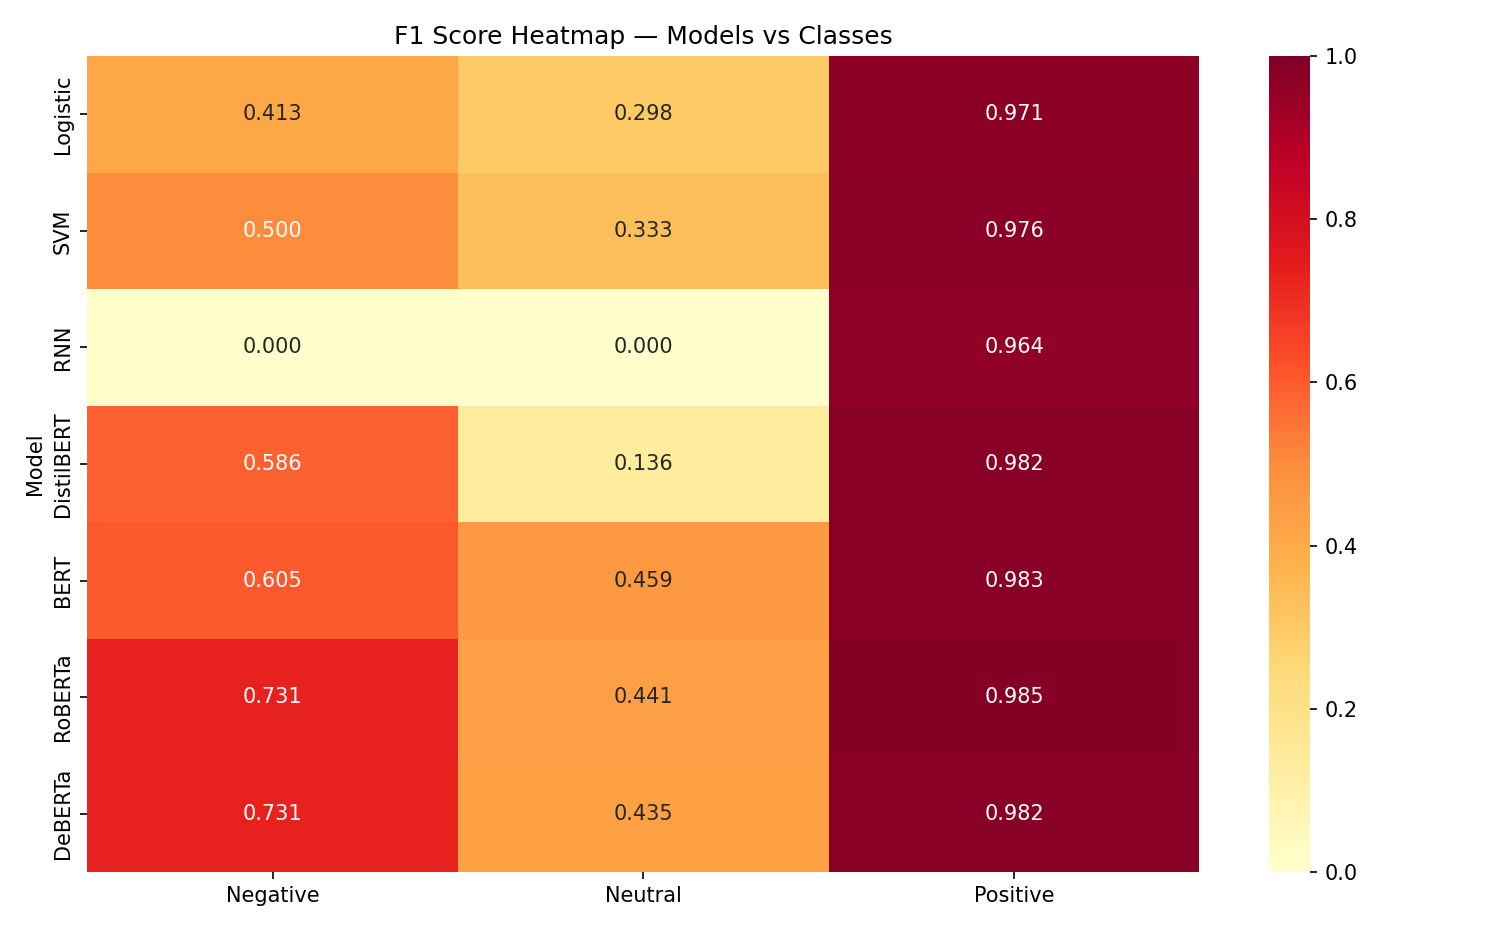


Displaying: report_multi_accuracy_bars.png


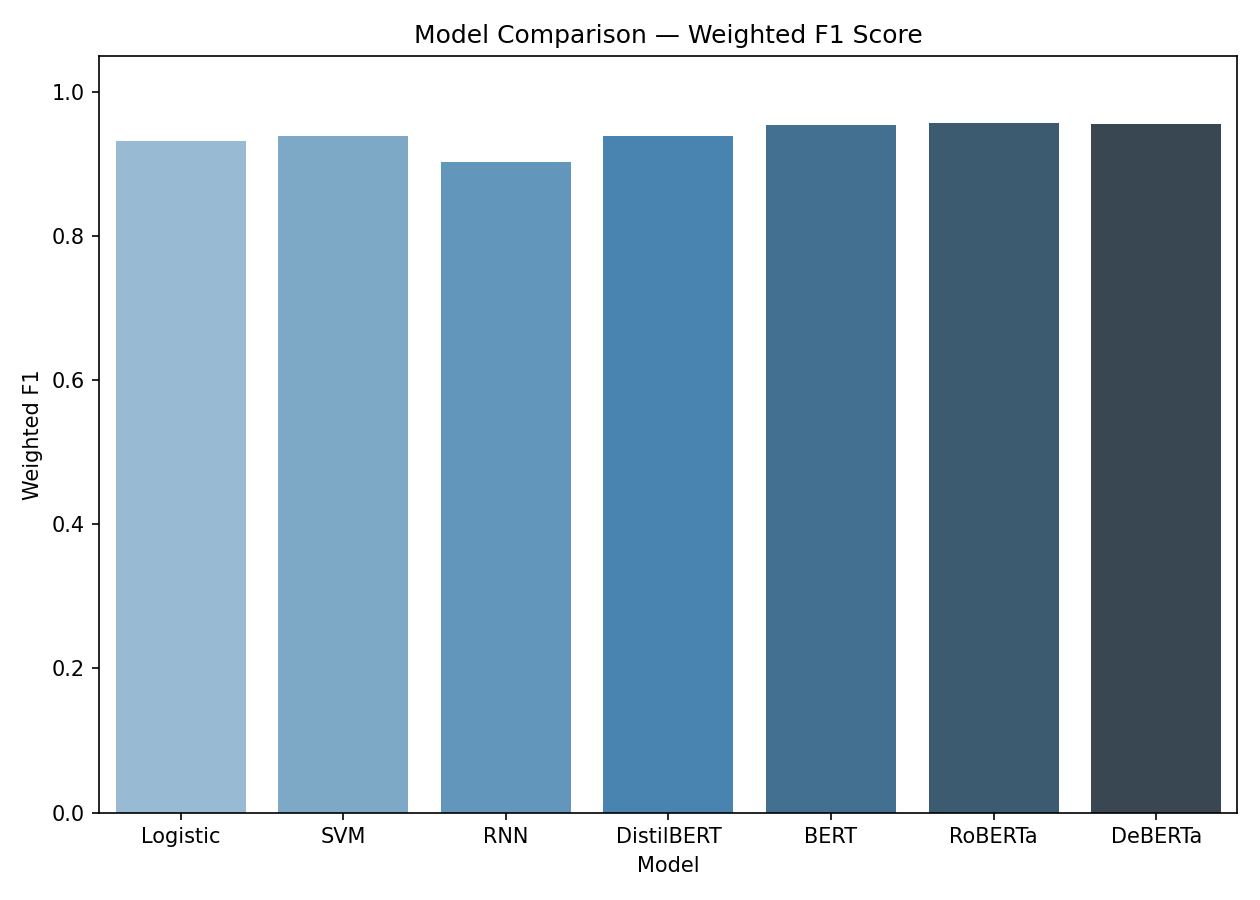


Displaying: report_multi_confusion_grid.png


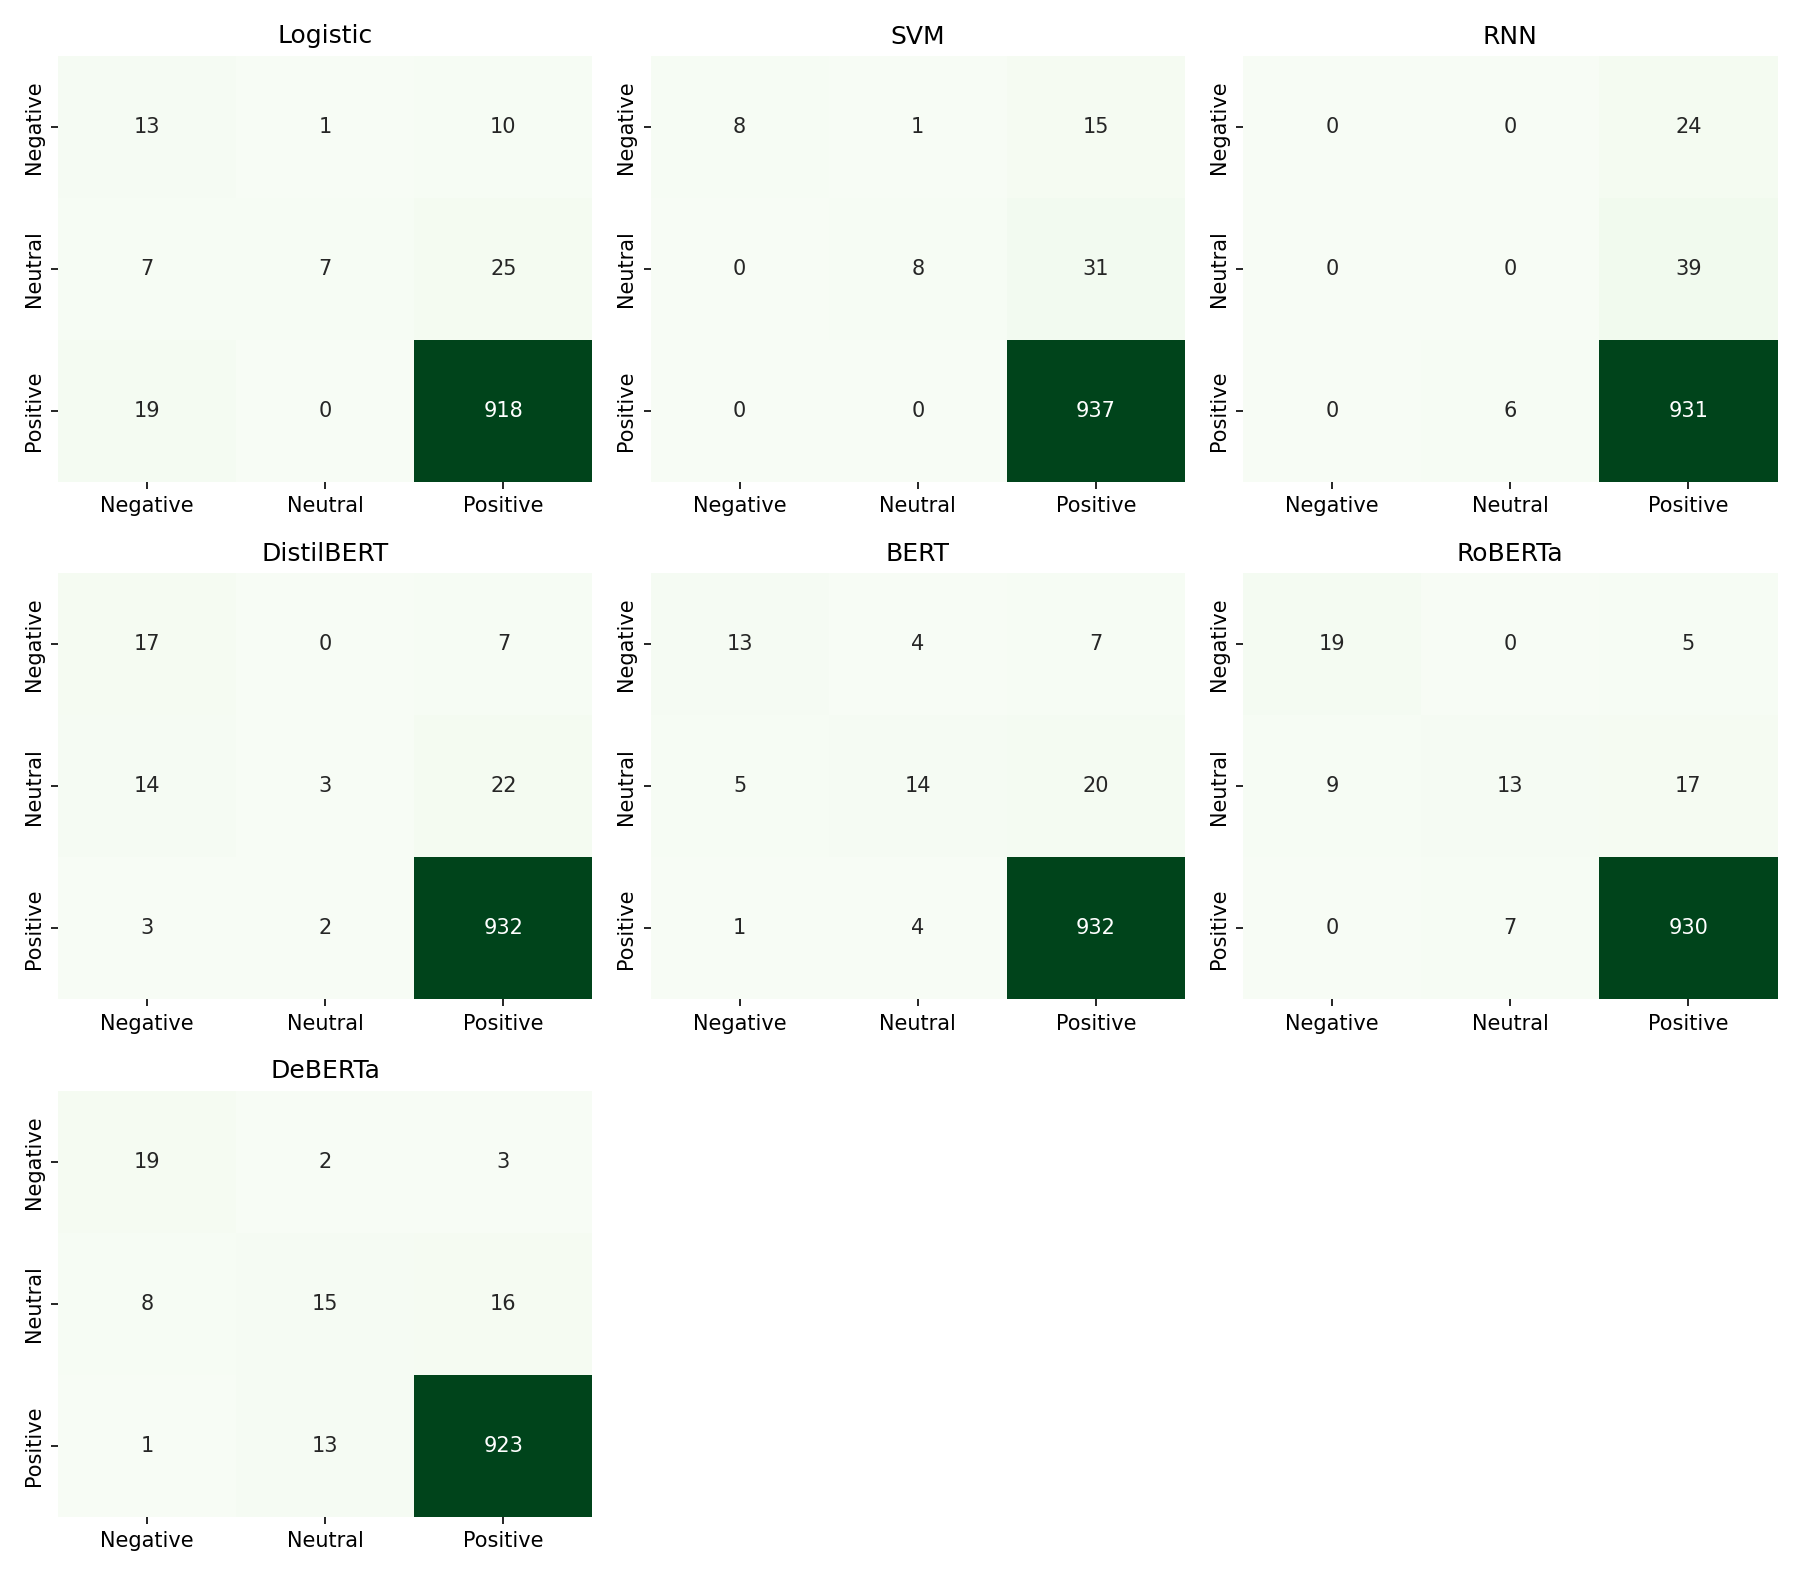


Displaying: report_wordclouds.png


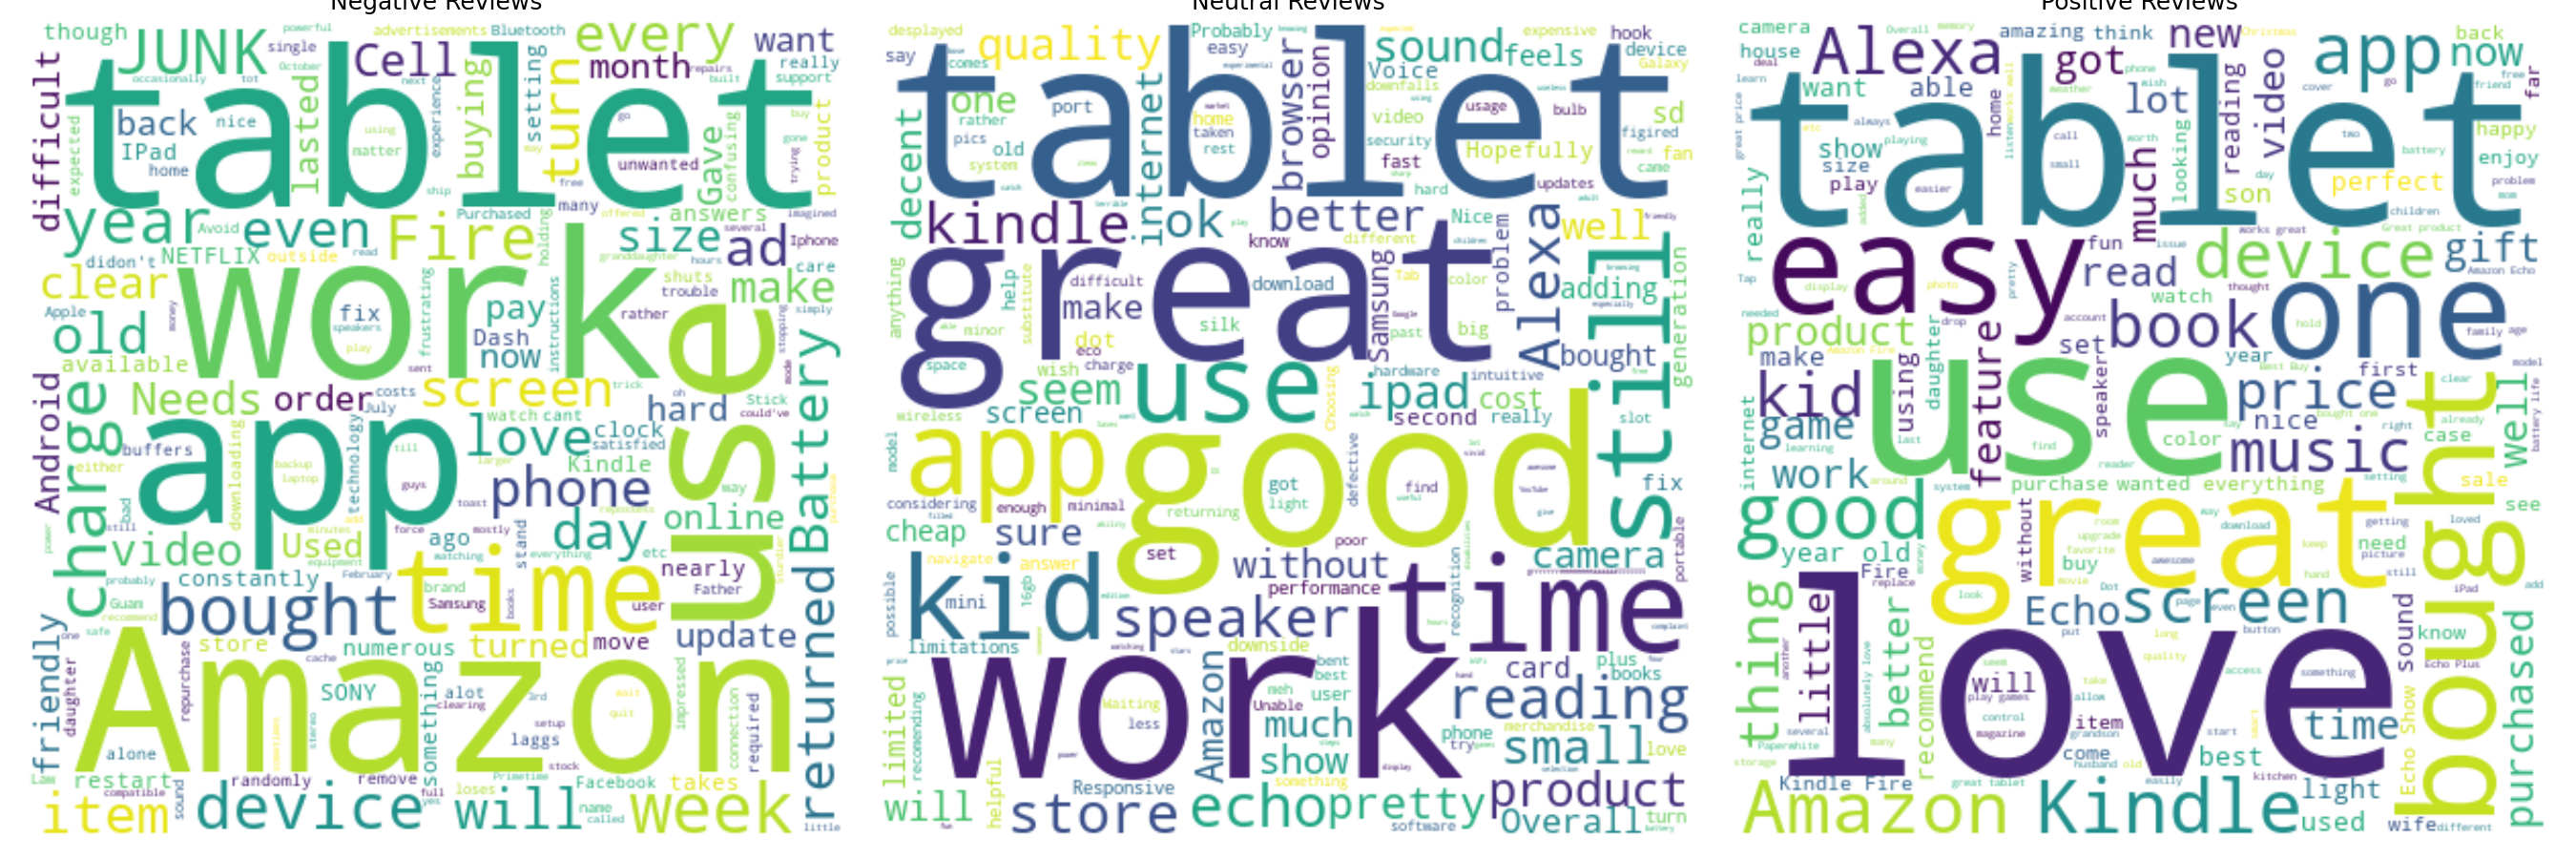


Displaying: report_aspect_analysis.png


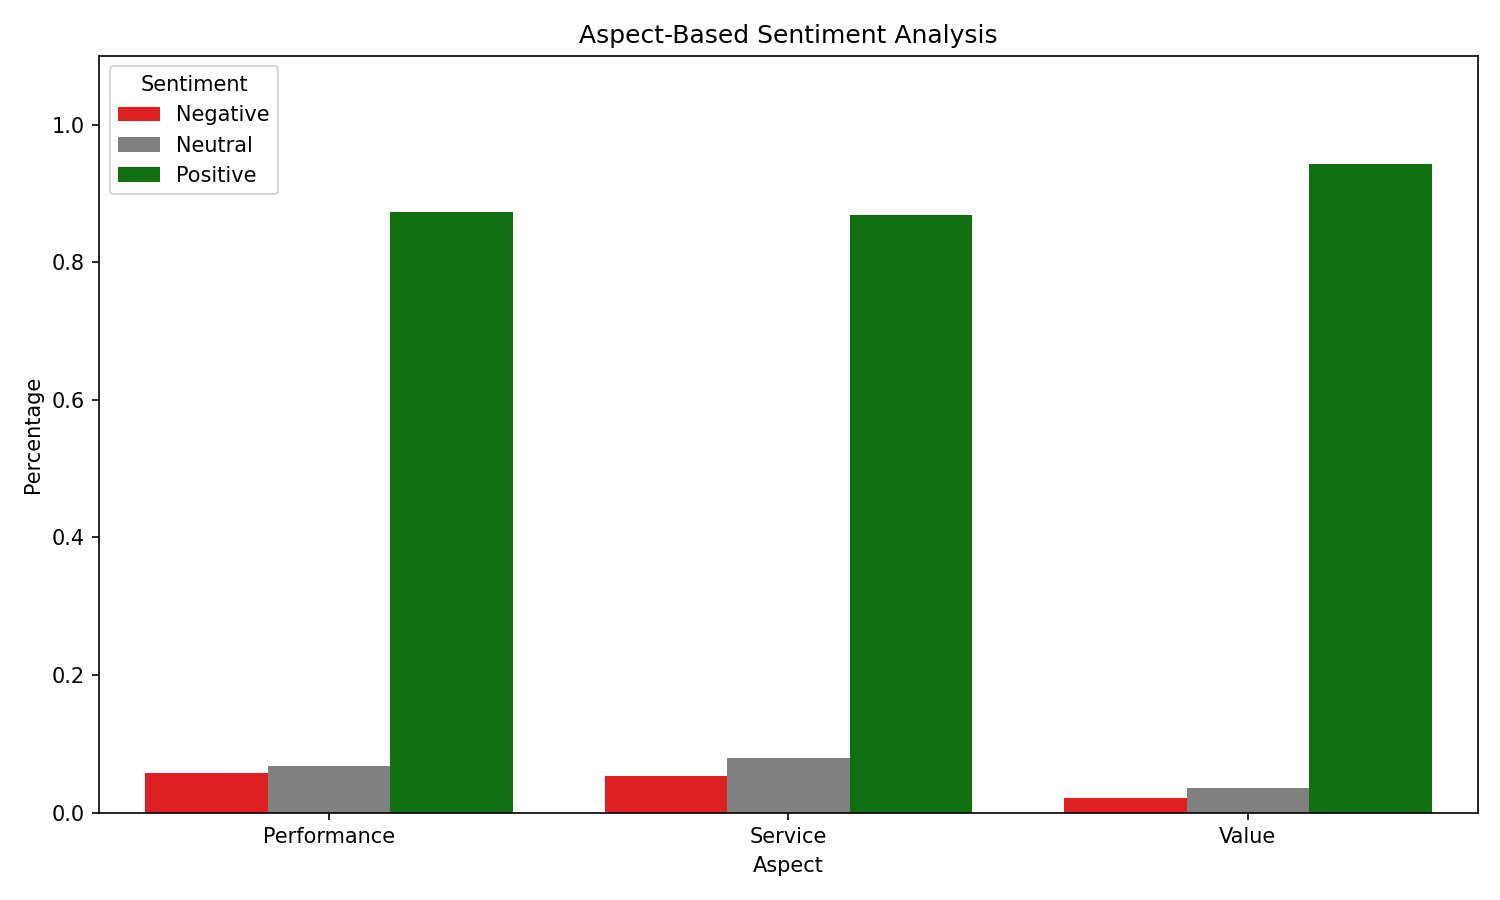


✅ PIPELINE COMPLETE
Reports saved in 'personal_update/outputs/'


In [6]:
import os
import sys
import pandas as pd

# Project root must be on sys.path
_REPO_ROOT = os.path.abspath(os.getcwd())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

from notebooks.sentiment_reporter import SentimentReporter
from notebooks.CapstoneData import DataExploration

reporter = SentimentReporter(output_dir='personal_update/outputs')
data_path = 'Ecommerce_dataset/test_data_hidden.csv'

# Instantiate and run the analysis
validation = DataExploration(data_path)

print("Generating Visual Analytics Report...")
reporter.generate_visualizations(validation.df)

print("\n✅ PIPELINE COMPLETE")
print("Reports saved in 'personal_update/outputs/'")

## 6. Classify Unlabeled Test Data (DeBERTa)
Run the DeBERTa model on `test_data.csv` to predict sentiments.

In [7]:
import pandas as pd
import tensorflow as tf
import sys
import os
sys.path.insert(0, os.path.abspath('notebooks'))
from notebooks.sentiment_analysis_DeBERTa import SentimentAnalysisDeBERTa

print("Loading DeBERTa model...")
deb = SentimentAnalysisDeBERTa(model_path="deploy_models/sentiment_model_deberta.pkl")

print("Loading test data...")
test_df = pd.read_csv("Ecommerce_dataset/test_data.csv")

# Ensure text columns are strings
test_df['reviews.text'] = test_df['reviews.text'].fillna('').astype(str)
test_df['reviews.title'] = test_df['reviews.title'].fillna('').astype(str)

print("Predicting sentiments for test_data.csv. This may take a moment...")
combined_texts = test_df['reviews.title'] + " " + test_df['reviews.text']

def predict_batch(sa, texts, batch_size=32):
    labels = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i : i + batch_size]
        enc = sa.tokenizer(list(chunk), add_special_tokens=True, max_length=sa.max_len, padding="max_length", truncation=True, return_tensors="tf")
        logits = sa.model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"]).logits
        pred = tf.argmax(logits, axis=1).numpy()
        labels.extend(sa.class_names[int(j)] for j in pred)
    return labels

test_df['predicted_sentiment'] = predict_batch(deb, combined_texts.tolist(), batch_size=32)
test_df.to_csv("Ecommerce_dataset/test_data_predicted.csv", index=False)
print("Saved predictions to Ecommerce_dataset/test_data_predicted.csv")


Loading DeBERTa model...
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


All model checkpoint layers were used when initializing TFDebertaV2ForSequenceClassification.

All the layers of TFDebertaV2ForSequenceClassification were initialized from the model checkpoint at /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2ForSequenceClassification for predictions without further training.
The tokenizer you are loading from '/Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model loaded from /Users/rohanghosh/Desktop/PlayGround/Ecommerce-Sentiment-Analysis/deploy_models/sentiment_model_deberta_deberta_tf
Loading test data...
Predicting sentiments for test_data.csv. This may take a moment...
Saved predictions to Ecommerce_dataset/test_data_predicted.csv


## 7. Combine All Datasets
Combine `train_data.csv`, `test_data_hidden.csv`, and our newly predicted `test_data_predicted.csv` into a single DataFrame.

In [8]:
train_df = pd.read_csv("Ecommerce_dataset/train_data.csv")
test_hidden_df = pd.read_csv("Ecommerce_dataset/test_data_hidden.csv")
test_pred_df = pd.read_csv("Ecommerce_dataset/test_data_predicted.csv")

if 'predicted_sentiment' in test_pred_df.columns:
    test_pred_df.rename(columns={'predicted_sentiment': 'sentiment'}, inplace=True)

common_cols = ['name', 'reviews.text', 'reviews.title', 'sentiment']
combined_df = pd.concat([
    train_df[[c for c in common_cols if c in train_df.columns]],
    test_hidden_df[[c for c in common_cols if c in test_hidden_df.columns]],
    test_pred_df[[c for c in common_cols if c in test_pred_df.columns]]
], ignore_index=True)

combined_df.to_csv("Ecommerce_dataset/combined_data.csv", index=False)
print(f"Combined data saved to Ecommerce_dataset/combined_data.csv with {len(combined_df)} rows.")


Combined data saved to Ecommerce_dataset/combined_data.csv with 6001 rows.


## 8. Aspect-Based Sentiment Analysis with BERTopic
Run BERTopic on the combined dataset to extract topics (aspects) for the Web UI.

In [9]:
from bertopic import BERTopic
import pandas as pd
import os

combined_df = pd.read_csv("Ecommerce_dataset/combined_data.csv")
combined_df['reviews.text'] = combined_df['reviews.text'].fillna('').astype(str)
docs = combined_df[combined_df['reviews.text'].str.strip() != '']['reviews.text'].tolist()
indices = combined_df[combined_df['reviews.text'].str.strip() != ''].index

print("Training BERTopic model...")
topic_model = BERTopic(language="english", calculate_probabilities=False, verbose=True)
topics, _ = topic_model.fit_transform(docs)

combined_df.loc[indices, 'topic'] = topics
topic_info = topic_model.get_topic_info()
topic_info['Name'] = topic_info['Name'].apply(lambda x: "General/Mixed" if x.startswith('-1_') else x.split('_', 1)[-1].replace('_', ', '))

topic_info.to_csv("deploy_models/bertopic_info.csv", index=False)
combined_df.to_csv("Ecommerce_dataset/combined_data_with_topics.csv", index=False)

os.makedirs("deploy_models/bertopic_model", exist_ok=True)
topic_model.save("deploy_models/bertopic_model", serialization="safetensors", save_ctfidf=True)
print("BERTopic modeling complete.")


2026-03-29 21:06:27,860 - BERTopic - Embedding - Transforming documents to embeddings.


Training BERTopic model...


Batches: 100%|██████████| 188/188 [00:06<00:00, 31.17it/s]
2026-03-29 21:06:37,596 - BERTopic - Embedding - Completed ✓
2026-03-29 21:06:37,596 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-29 21:06:49,120 - BERTopic - Dimensionality - Completed ✓
2026-03-29 21:06:49,121 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-29 21:06:49,224 - BERTopic - Cluster - Completed ✓
2026-03-29 21:06:49,226 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-29 21:06:49,352 - BERTopic - Representation - Completed ✓


BERTopic modeling complete.


## 9. Launch Sentiment Dashboard
Run the cell below to see instructions for launching the interactive Web UI.

In [12]:
print("Dashboard is ready!")
print("To launch the web interface, run the following command in your terminal:")
print("    PYTHONPATH=. python app.py")
print("\nOnce running, open http://127.0.0.1:5001 in your browser.")


Dashboard is ready!
To launch the web interface, run the following command in your terminal:
    PYTHONPATH=. python app.py

Once running, open http://127.0.0.1:5001 in your browser.
